# Comprehensive Descriptive Statistical Analysis - 10-Class Vegetable Dataset

Bộ dữ liệu: Hình ảnh rau củ gồm 10 class: asparagus, banana, broccoli, carrot, corn, eggplant, orange, pineapple, potato, tomato

---

## Library Installation and Configuration

In [6]:
import os 
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.stats import gaussian_kde

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DATA_ROOT = '../data/raw/image_data/'
TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
VAL_DIR   = os.path.join(DATA_ROOT, 'val')
TEST_DIR  = os.path.join(DATA_ROOT, 'test')

CLASSES = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
print(f'Số lượng class: {len(CLASSES)}')
print(f'Danh sách class: {CLASSES}')

Số lượng class: 10
Danh sách class: ['asparagus', 'banana', 'broccoli', 'carrot', 'corn', 'eggplant', 'orange', 'pineapple', 'potato', 'tomato']


### Tổng quan về bộ dữ liệu

In [7]:
def collect_images(root_dir):
    """Thu thập tất cả đường dẫn ảnh theo class từ một thư mục gốc."""
    records = []
    for cls in CLASSES:
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.exists(cls_dir):
            continue
        for ext in ('*.jpg', '*.jpeg', '*.png', '*.bmp', '*.webp'):
            pattern = os.path.join(cls_dir, ext)
            for fp in glob.glob(pattern):
                split_name = os.path.basename(root_dir)
                records.append({'class': cls, 'path': fp, 'split': split_name})
    return records

# Thu thập ảnh từ cả 3 tập
all_records = []
for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    all_records.extend(collect_images(split_dir))

df_meta = pd.DataFrame(all_records)
print(f'Tổng số ảnh: {len(df_meta)}')
print(df_meta.groupby(['split', 'class']).size().unstack(fill_value=0))

Tổng số ảnh: 10000
class  asparagus  banana  broccoli  carrot  corn  eggplant  orange  pineapple  \
split                                                                           
test         150     150       150     150   150       150     150        150   
train        700     700       700     700   700       700     700        700   
val          150     150       150     150   150       150     150        150   

class  potato  tomato  
split                  
test      150     150  
train     700     700  
val       150     150  


In [25]:
def get_image_size(filepath):
    with Image.open(filepath) as img:
        return img.size  # Trả về tuple (width, height)

df_meta[['width', 'height']] = df_meta['path'].apply(lambda x: pd.Series(get_image_size(x)))

print(f"Các giá trị chiều rộng của ảnh là: {df_meta['width'].unique()}")
print(f"Các giá trị chiều cao của ảnh là: {df_meta['height'].unique()}")


Các giá trị chiều rộng của ảnh là: [740]
Các giá trị chiều cao của ảnh là: [ 493 1110  555  867  759 1455  492  740 1109  925  503  320 1104 1136
  494  416 1118  525  993  813  517  451  592 1538  490  901  706  621
  513  649  516 1046  535 1117  542  376  794 1070 1149 1013  495  840
  936  399 1016  629  632  458  991 1076  998 1112  543  417 1108 1234
 1170 1249  561  841  557  569  691  506  519  883  463  501  471  790
  441  987  553  491 1297 1195  465  415  515  537  464  889  346 1072
  906  405  364  397  960 1139  483 1163  344  421  340  460  500  631
  333 1012  420 1148 1114  444  717  529  445  741  413  453  454  597
  385  508  743  648  504  437  358  396 1005 1098  474  480 1023  489
 1196  551  339  423 1563 1049 1004  289  496 1160 1368 1083  536  531
  918  422  502  473  563  498  822  247  825  518  613  786  573  576
  972  526  514  522  755  512  646  539  477  548  456  544  564  837
  430  559  478  523  547  472  534  528  455  509  720  578  343  461
  

---
## Part A - Pixel Value Distribution by Color Channel (Histogram + KDE)

Phần này tính và trực quan hóa phân phối giá trị pixel trên toàn tập, chia theo 3 kênh màu R (đỏ), G (xanh lá), B (xanh lam).

In [8]:
SAMPLE_SIZE = min(500, len(df_meta))
df_sample = df_meta.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

channel_pixels = {'R': [], 'G': [], 'B': []}
channel_means_per_image = []  # trung bình mỗi kênh mỗi ảnh

for _, row in df_sample.iterrows():
    try:
        img = Image.open(row['path']).convert('RGB').resize((64, 64))
        arr = np.array(img, dtype=np.float32)
        channel_pixels['R'].extend(arr[:, :, 0].flatten().tolist())
        channel_pixels['G'].extend(arr[:, :, 1].flatten().tolist())
        channel_pixels['B'].extend(arr[:, :, 2].flatten().tolist())
        channel_means_per_image.append({
            'class': row['class'],
            'mean_R': arr[:, :, 0].mean(),
            'mean_G': arr[:, :, 1].mean(),
            'mean_B': arr[:, :, 2].mean(),
            'std_R': arr[:, :, 0].std(),
            'std_G': arr[:, :, 1].std(),
            'std_B': arr[:, :, 2].std(),
        })
    except Exception:
        pass

df_pixel_stats = pd.DataFrame(channel_means_per_image)
print(f'Đã xử lý: {len(df_pixel_stats)} ảnh')

# Thống kê tổng quan - LƯU VÀO BIẾN PYTHON
pixel_mean_R = np.mean(channel_pixels['R'])
pixel_mean_G = np.mean(channel_pixels['G'])
pixel_mean_B = np.mean(channel_pixels['B'])
pixel_std_R = np.std(channel_pixels['R'])
pixel_std_G = np.std(channel_pixels['G'])
pixel_std_B = np.std(channel_pixels['B'])
pixel_median_R = np.median(channel_pixels['R'])
pixel_median_G = np.median(channel_pixels['G'])
pixel_median_B = np.median(channel_pixels['B'])
pixel_min_R = np.min(channel_pixels['R'])
pixel_min_G = np.min(channel_pixels['G'])
pixel_min_B = np.min(channel_pixels['B'])
pixel_max_R = np.max(channel_pixels['R'])
pixel_max_G = np.max(channel_pixels['G'])
pixel_max_B = np.max(channel_pixels['B'])

print('\nThống kê giá trị pixel tổng quan (0-255):')
stats_table = pd.DataFrame({
    'Kênh': ['R (Đỏ)', 'G (Xanh lá)', 'B (Xanh lam)'],
    'Trung bình': [pixel_mean_R, pixel_mean_G, pixel_mean_B],
    'Độ lệch chuẩn': [pixel_std_R, pixel_std_G, pixel_std_B],
    'Trung vị': [pixel_median_R, pixel_median_G, pixel_median_B],
    'Min': [pixel_min_R, pixel_min_G, pixel_min_B],
    'Max': [pixel_max_R, pixel_max_G, pixel_max_B],
})
stats_table = stats_table.set_index('Kênh')
print(stats_table.round(2))

Đã xử lý: 500 ảnh

Thống kê giá trị pixel tổng quan (0-255):
              Trung bình  Độ lệch chuẩn  Trung vị  Min    Max
Kênh                                                         
R (Đỏ)            189.00          73.85     220.0  0.0  255.0
G (Xanh lá)       172.55          76.17     188.0  0.0  255.0
B (Xanh lam)      144.89          91.86     144.0  0.0  255.0


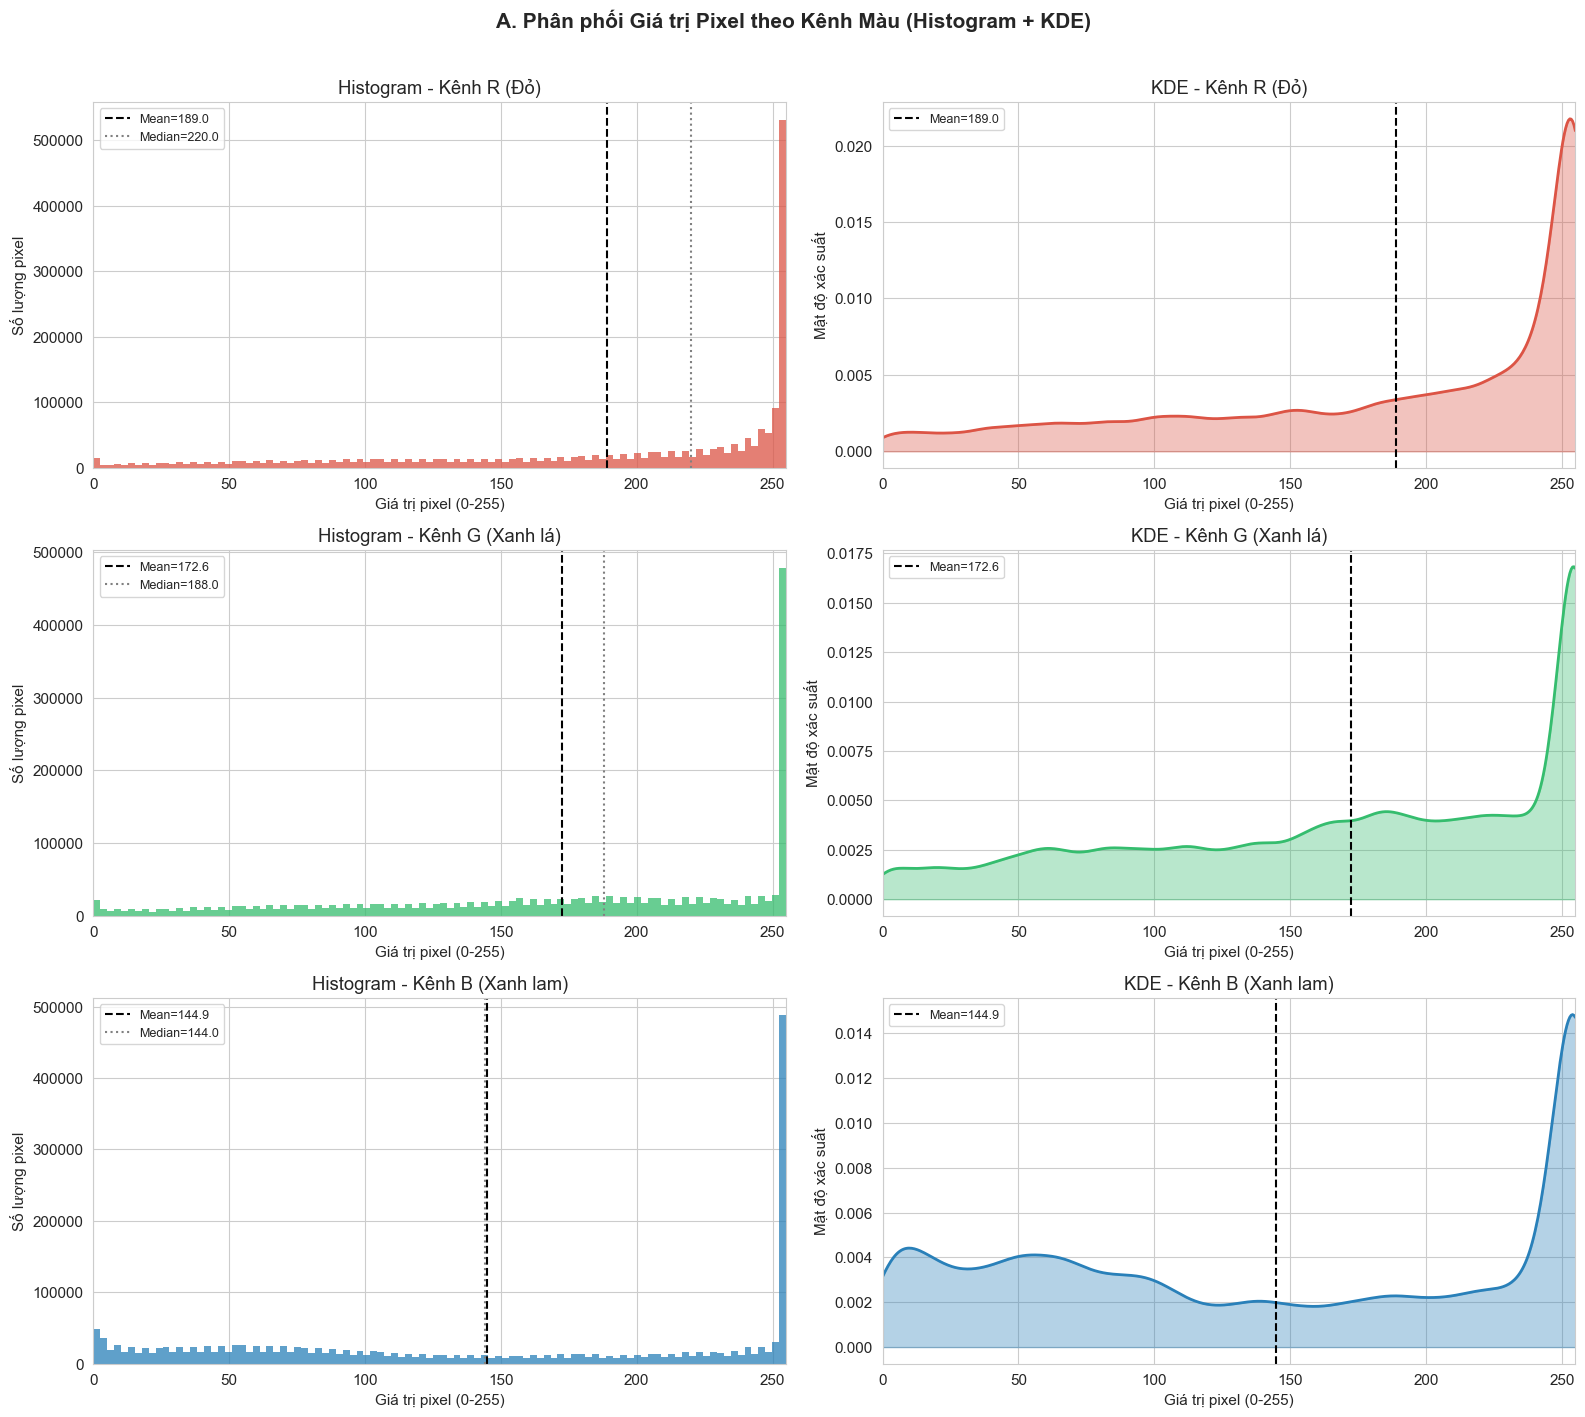

In [9]:
# Vẽ Histogram + KDE cho từng kênh màu
COLORS = {'R': "#dc5445", 'G': "#35bd6e", 'B': '#2980b9'}
CHANNEL_NAMES = {'R': 'Kênh R (Đỏ)', 'G': 'Kênh G (Xanh lá)', 'B': 'Kênh B (Xanh lam)'}

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('A. Phân phối Giá trị Pixel theo Kênh Màu (Histogram + KDE)', fontsize=15, fontweight='bold', y=1.01)

for i, ch in enumerate(['R', 'G', 'B']):
    pixels = np.array(channel_pixels[ch])
    
    # Histogram
    ax_hist = axes[i][0]
    ax_hist.hist(pixels, bins=100, color=COLORS[ch], alpha=0.75, edgecolor='none')
    ax_hist.axvline(pixels.mean(), color='black', linestyle='--', linewidth=1.5,
                    label=f'Mean={pixels.mean():.1f}')
    ax_hist.axvline(np.median(pixels), color='gray', linestyle=':', linewidth=1.5,
                    label=f'Median={np.median(pixels):.1f}')
    ax_hist.set_title(f'Histogram - {CHANNEL_NAMES[ch]}')
    ax_hist.set_xlabel('Giá trị pixel (0-255)')
    ax_hist.set_ylabel('Số lượng pixel')
    ax_hist.legend(fontsize=9)
    ax_hist.set_xlim([0, 255])
    
    # KDE
    ax_kde = axes[i][1]
    sample_for_kde = pixels[np.random.choice(len(pixels), size=min(5000, len(pixels)), replace=False)]
    kde = gaussian_kde(sample_for_kde, bw_method=0.08)
    x_range = np.linspace(0, 255, 500)
    ax_kde.fill_between(x_range, kde(x_range), alpha=0.35, color=COLORS[ch])
    ax_kde.plot(x_range, kde(x_range), color=COLORS[ch], linewidth=2)
    ax_kde.axvline(pixels.mean(), color='black', linestyle='--', linewidth=1.5,
                   label=f'Mean={pixels.mean():.1f}')
    ax_kde.set_title(f'KDE - {CHANNEL_NAMES[ch]}')
    ax_kde.set_xlabel('Giá trị pixel (0-255)')
    ax_kde.set_ylabel('Mật độ xác suất')
    ax_kde.set_xlim([0, 255])
    ax_kde.legend(fontsize=9)

plt.tight_layout()
plt.show()


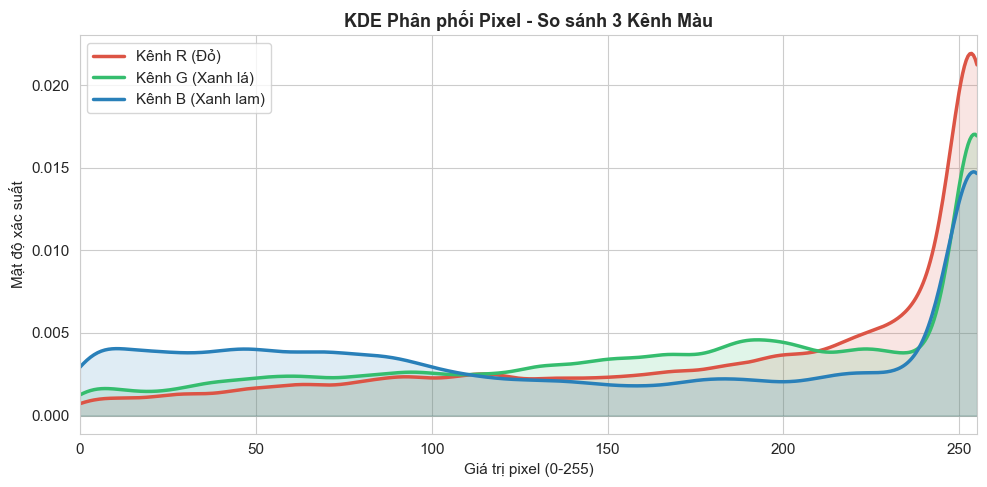

In [10]:
# Vẽ tất cả 3 kênh KDE trên cùng một biểu đồ
fig, ax = plt.subplots(figsize=(10, 5))
for ch in ['R', 'G', 'B']:
    pixels = np.array(channel_pixels[ch])
    sample_for_kde = pixels[np.random.choice(len(pixels), size=min(5000, len(pixels)), replace=False)]
    kde = gaussian_kde(sample_for_kde, bw_method=0.08)
    x_range = np.linspace(0, 255, 500)
    ax.plot(x_range, kde(x_range), color=COLORS[ch], linewidth=2.5, label=CHANNEL_NAMES[ch])
    ax.fill_between(x_range, kde(x_range), alpha=0.15, color=COLORS[ch])

ax.set_title('KDE Phân phối Pixel - So sánh 3 Kênh Màu', fontsize=13, fontweight='bold')
ax.set_xlabel('Giá trị pixel (0-255)')
ax.set_ylabel('Mật độ xác suất')
ax.set_xlim([0, 255])
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()



---
## Part B - Class Imbalance Analysis

Phần này tính tỉ lệ mỗi class trên toàn bộ dữ liệu, kiểm tra xem có lớp nào vượt quá ngưỡng 3 lần so với lớp ít nhất không.

In [11]:
# Đếm số ảnh theo class (toàn bộ tập)
class_counts = df_meta.groupby('class').size().sort_values(ascending=False)
total_images = class_counts.sum()
class_ratio = (class_counts / total_images * 100).round(2)

df_imbalance = pd.DataFrame({
    'Số ảnh': class_counts,
    'Tỉ lệ (%)': class_ratio
})

min_count = class_counts.min()
max_count = class_counts.max()
imbalance_ratio = max_count / min_count

print('PHÂN TÍCH MẤT CÂN BẰNG LỚP')
print(f'Tổng số ảnh: {total_images}')
print(f'Lớp ít nhất: {class_counts.idxmin()} ({min_count} ảnh)')
print(f'Lớp nhiều nhất: {class_counts.idxmax()} ({max_count} ảnh)')
print(f'Tỉ lệ mất cân bằng (max/min): {imbalance_ratio:.2f}x')
print()
print('Chi tiết từng class:')
print(df_imbalance.to_string())
print()

# Kiểm tra lớp vượt ngưỡng 3x - LƯU VÀO BIẾN PYTHON
threshold_3x = min_count * 3
overrepresented_classes = class_counts[class_counts > threshold_3x]
overrepresented_dict = {cls: int(cnt) for cls, cnt in overrepresented_classes.items()}
num_overrepresented = len(overrepresented_classes)

if len(overrepresented_classes) > 0:
    print(f'CẢNH BÁO: Các lớp vượt quá ngưỡng 3x (>{threshold_3x} ảnh):')
    for cls, cnt in overrepresented_classes.items():
        print(f'  - {cls}: {cnt} ảnh ({cnt/min_count:.1f}x so với lớp nhỏ nhất)')
else:
    print(f'Kết quả: Không có lớp nào vượt ngưỡng 3x (ngưỡng = {threshold_3x} ảnh)')
    print('Bộ dữ liệu tương đối cân bằng.')

PHÂN TÍCH MẤT CÂN BẰNG LỚP
Tổng số ảnh: 10000
Lớp ít nhất: asparagus (1000 ảnh)
Lớp nhiều nhất: asparagus (1000 ảnh)
Tỉ lệ mất cân bằng (max/min): 1.00x

Chi tiết từng class:
           Số ảnh  Tỉ lệ (%)
class                       
asparagus    1000       10.0
banana       1000       10.0
broccoli     1000       10.0
carrot       1000       10.0
corn         1000       10.0
eggplant     1000       10.0
orange       1000       10.0
pineapple    1000       10.0
potato       1000       10.0
tomato       1000       10.0

Kết quả: Không có lớp nào vượt ngưỡng 3x (ngưỡng = 3000 ảnh)
Bộ dữ liệu tương đối cân bằng.


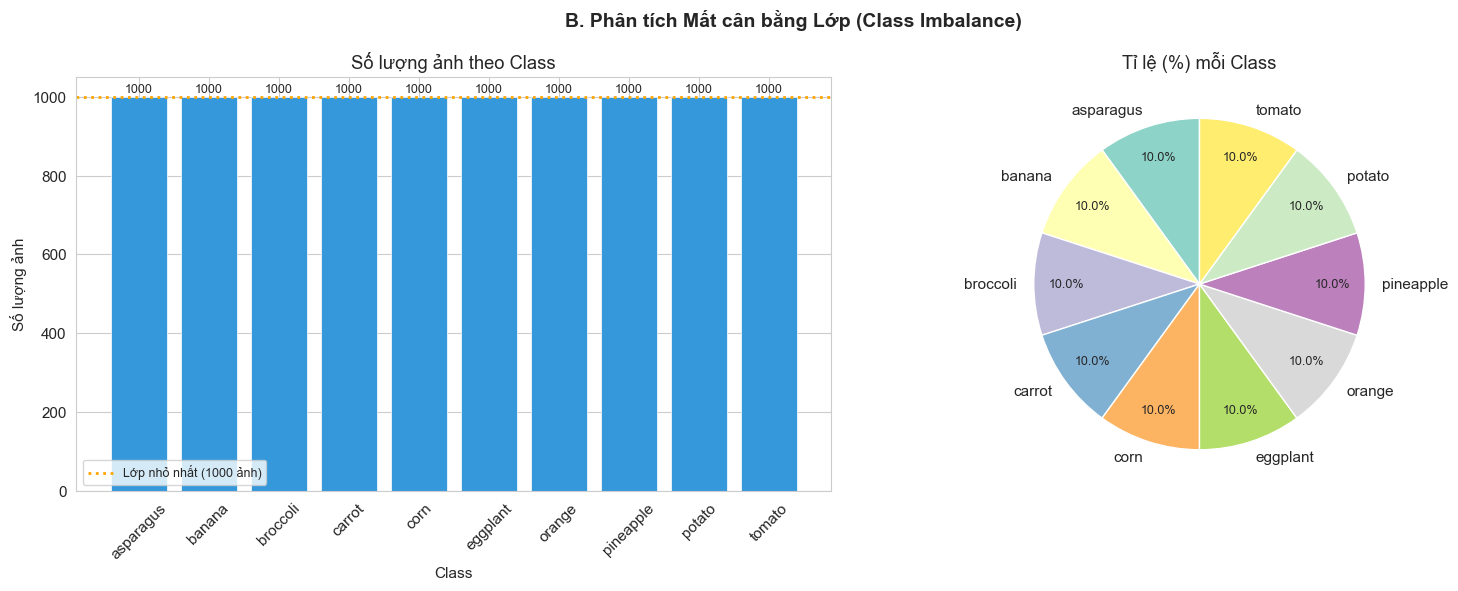

In [12]:
# Vẽ biểu đồ phân tích class imbalance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('B. Phân tích Mất cân bằng Lớp (Class Imbalance)', fontsize=14, fontweight='bold')

# Bar chart
ax1 = axes[0]
colors_bar = ['#e74c3c' if c > threshold_3x else '#3498db' for c in class_counts.values]
bars = ax1.bar(class_counts.index, class_counts.values, color=colors_bar, edgecolor='white', linewidth=0.5)
ax1.axhline(y=min_count, color='orange', linestyle=':', linewidth=2,
            label=f'Lớp nhỏ nhất ({min_count} ảnh)')
ax1.set_title('Số lượng ảnh theo Class')
ax1.set_xlabel('Class')
ax1.set_ylabel('Số lượng ảnh')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(fontsize=9)
for bar, val in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
             str(val), ha='center', va='bottom', fontsize=9)

# Pie chart ti le
ax2 = axes[1]
wedge_colors = plt.cm.Set3(np.linspace(0, 1, len(class_counts)))
wedges, texts, autotexts = ax2.pie(
    class_counts.values, labels=class_counts.index,
    autopct='%1.1f%%', startangle=90,
    colors=wedge_colors, pctdistance=0.8
)
for text in autotexts:
    text.set_fontsize(9)
ax2.set_title('Tỉ lệ (%) mỗi Class')

plt.tight_layout()
plt.show()

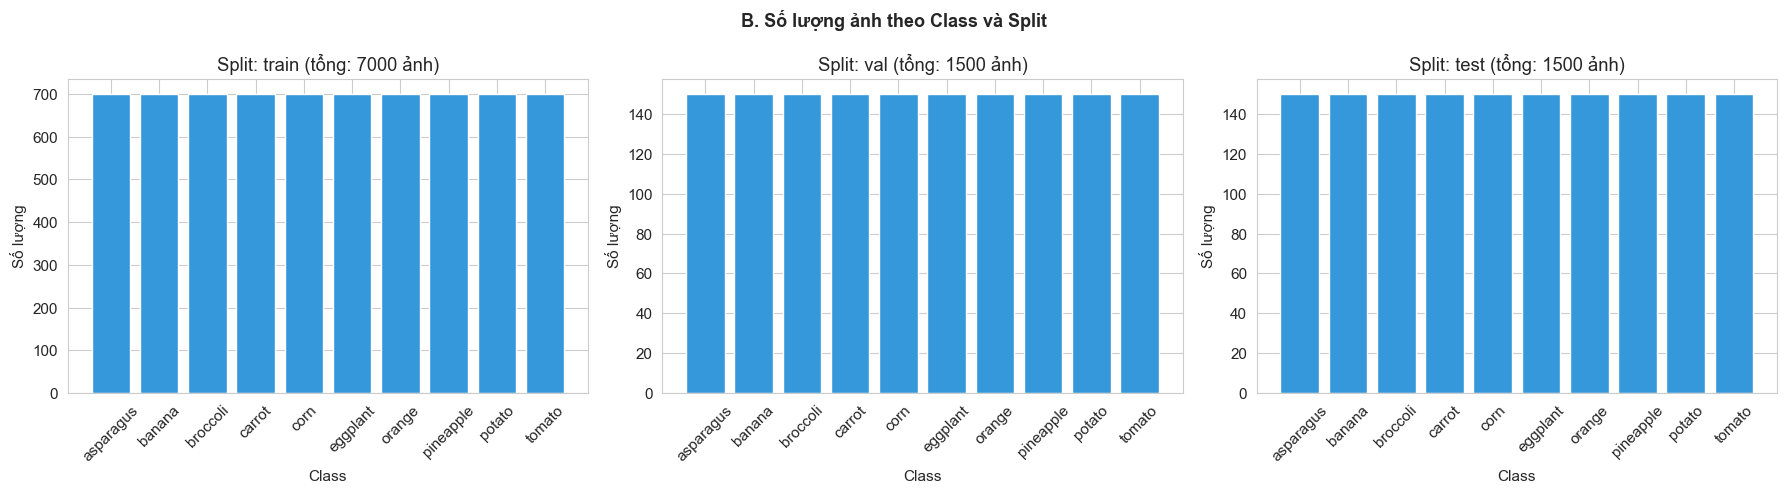

In [13]:
# Vẽ theo từng split (train / val / test)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('B. Số lượng ảnh theo Class và Split', fontsize=13, fontweight='bold')

for ax, split in zip(axes, ['train', 'val', 'test']):
    df_split = df_meta[df_meta['split'] == split]
    if len(df_split) == 0:
        ax.set_title(f'Split: {split} (không có dữ liệu)')
        continue
    counts = df_split.groupby('class').size().reindex(CLASSES, fill_value=0)
    ax.bar(counts.index, counts.values, color='#3498db', edgecolor='white')
    ax.set_title(f'Split: {split} (tổng: {len(df_split)} ảnh)')
    ax.set_xlabel('Class')
    ax.set_ylabel('Số lượng')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


---
## Part C - Duplicate Detection using Perceptual Hash (pHash)


In [14]:
def compute_phash(image_path, hash_size=32):
    """
    Tính Perceptual Hash cho ảnh mà không dùng thư viện imagehash.
    
    Quy trình:
    1. Resize ảnh thành hash_size x hash_size
    2. Convert to grayscale
    3. Tính average pixel value
    4. Tạo binary string: 1 nếu pixel > average, 0 nếu pixel <= average
    5. Trả về hex string của hash
    """
    try:
        img = Image.open(image_path).convert('RGB')
        # Resize to 32x32
        img_resized = img.resize((hash_size, hash_size), Image.Resampling.LANCZOS)
        # Convert to grayscale
        img_gray = img_resized.convert('L')
        # Get pixel array
        pixels = np.array(img_gray, dtype=np.float32).flatten()
        # Calculate average
        avg = np.mean(pixels)
        # Create binary hash: 1 if pixel > avg, else 0
        phash_bits = ''.join(['1' if p > avg else '0' for p in pixels])
        # Convert to hex
        phash_hex = hex(int(phash_bits, 2))[2:].zfill(16)
        return phash_hex
    except Exception as e:
        return None

def hamming_distance(hash1, hash2):
    """Tính Hamming distance giữa 2 hex hash strings"""
    if hash1 is None or hash2 is None:
        return float('inf')
    try:
        # Convert hex to int
        h1 = int(hash1, 16)
        h2 = int(hash2, 16)
        # XOR và count bits
        xor_result = h1 ^ h2
        return bin(xor_result).count('1')
    except:
        return float('inf')

# Tính pHash cho tất cả ảnh
print('Đang tính pHash cho toàn bộ tập dữ liệu...')

hash_records = []
error_count = 0

total_images = len(df_meta)

for idx, (_, row) in enumerate(df_meta.iterrows(), start=1):

    phash_val = compute_phash(row['path'])

    if phash_val is not None:
        hash_records.append({
            'class': row['class'],
            'split': row['split'],
            'path': row['path'],
            'phash': phash_val
        })
    else:
        error_count += 1

    print(
        f"Đã xử lý: {idx}/{total_images} ảnh | Lỗi: {error_count}",
        end="\r"
    )

print()

df_hash = pd.DataFrame(hash_records)

print(f'Đã tính phash: {len(df_hash)} ảnh')
print(f'Lỗi: {error_count} ảnh')


Đang tính pHash cho toàn bộ tập dữ liệu...
Đã xử lý: 10000/10000 ảnh | Lỗi: 0
Đã tính phash: 10000 ảnh
Lỗi: 0 ảnh


In [15]:
# === PHÁT HIỆN TRÙNG LẶP CHÍNH XÁC (Hamming distance = 0) ===
if len(hash_records) > 0:
    # Phát hiện ảnh trùng lặp chính xác
    dup_total_images = len(df_hash)
    exact_dup_groups = df_hash.groupby('phash').filter(lambda x: len(x) > 1)
    dup_n_exact_dup_imgs = len(exact_dup_groups)
    dup_n_exact_dup_groups = df_hash[df_hash.duplicated('phash', keep=False)]['phash'].nunique()
    
    # Tính số ảnh cần xóa (giữ lại 1 ảnh mỗi nhóm)
    dup_imgs_to_remove = df_hash.duplicated('phash', keep='first').sum()
    dup_ratio_exact = (dup_imgs_to_remove/dup_total_images*100) if dup_total_images > 0 else 0
    
    print('=== PHÁT HIỆN TRÙNG LẶP CHÍNH XÁC (pHash Identical - Hamming=0) ===')
    print(f'Tổng số ảnh đã quét: {dup_total_images}')
    print(f'Số nhóm trùng lặp chính xác: {dup_n_exact_dup_groups}')
    print(f'Số ảnh nằm trong nhóm trùng lặp: {dup_n_exact_dup_imgs}')
    print(f'Số ảnh có thể xóa bỏ: {dup_imgs_to_remove}')
    print(f'Tỉ lệ trùng lặp chính xác: {dup_ratio_exact:.2f}%')
    print()
    
    if dup_n_exact_dup_groups > 0:
        print('Chi tiết các nhóm trùng lặp (tối đa 5 nhóm đầu):')
        dup_detail = df_hash[df_hash.duplicated('phash', keep=False)].groupby('phash').apply(
            lambda g: list(g[['class', 'split', 'path']].itertuples(index=False, name=None))
        ).head(5)
        dup_detail_list = list(dup_detail.items())
        for phash_val, group in dup_detail_list:
            print(f'  Hash: {phash_val[:10]}...')
            for item in group:
                print(f'    - [{item[1]}] {os.path.basename(item[2])}')
    else:
        print('Không phát hiện ảnh trùng lặp chính xác.')


=== PHÁT HIỆN TRÙNG LẶP CHÍNH XÁC (pHash Identical - Hamming=0) ===
Tổng số ảnh đã quét: 10000
Số nhóm trùng lặp chính xác: 68
Số ảnh nằm trong nhóm trùng lặp: 138
Số ảnh có thể xóa bỏ: 70
Tỉ lệ trùng lặp chính xác: 0.70%

Chi tiết các nhóm trùng lặp (tối đa 5 nhóm đầu):
  Hash: 1bfffff8b9...
    - [train] eggplant2921.jpg
    - [test] eggplant2984.jpg
  Hash: 280000003c...
    - [train] corn651.jpg
    - [train] corn654.jpg
  Hash: 7e000000ff...
    - [train] broccoli2810.jpg
    - [train] broccoli2835.jpg
  Hash: 80000003c0...
    - [train] broccoli2375.jpg
    - [val] broccoli1872.jpg
  Hash: 8000c610dc...
    - [train] corn611.jpg
    - [train] corn684.jpg


**Nhận xét Phần C:**
- **pHash (Perceptual Hash)**: Mã hóa nội dung trực quan của ảnh thành chuỗi hexadecimal 32-bit
- **Hamming distance = 0**: Ảnh trùng lặp chính xác (giống hệt nhau về nội dung trực quan)
- **Xử lý**: Các ảnh trùng lặp cần được loại bỏ để tránh data leakage và overfitting trong training
- **Lưu ý**: Code xóa file đã được comment lại. Hãy kiểm tra danh sách trước khi uncomment và thực hiện xóa.
- Xóa các ảnh trùng lặp để tránh trường hợp model có thể học vẹt, hoặc biết trước đề.
---


In [16]:
# XỬ LÝ TRÙNG LẶP
if len(hash_records) > 0:
    # Chuẩn bị dữ liệu xử lý trùng lặp - LƯU VÀO BIẾN
    df_hash_clean = df_hash.drop_duplicates(subset='phash', keep='first').copy()
    dup_images_before_cleaning = len(df_hash)
    dup_images_removed = len(df_hash) - len(df_hash_clean)
    dup_images_after_cleaning = len(df_hash_clean)
    dup_cleanup_ratio = (dup_images_removed/len(df_hash)*100) if len(df_hash) > 0 else 0
    
    print('=== THỐNG KÊ XỬ LÝ TRÙNG LẶP ===')
    print(f'Trước xử lý: {dup_images_before_cleaning} ảnh')
    print(f'Ảnh trùng lặp cần xóa: {dup_images_removed} ảnh')
    print(f'Sau xử lý: {dup_images_after_cleaning} ảnh')
    print(f'Tỉ lệ giảm: {dup_cleanup_ratio:.2f}%')
    print()
    
    # Chuẩn bị danh sách ảnh cần xóa
    duplicates_to_remove = df_hash[df_hash.duplicated('phash', keep='first')]
    
    if len(duplicates_to_remove) > 0:
        pass
        
        # PHẦN XÓA CHƯA ĐƯỢC ENABLE - HÃY UNCOMMENT NẾU MUỐN THỰC HIỆN
        # out_path = os.path.join(DATA_ROOT, 'duplicate_images_list.csv')
        # duplicates_to_remove.to_csv(out_path, index=False)
        # print(f'\nDanh sách ảnh trùng lặp đã lưu: {out_path}')
        # print('(Kiểm tra danh sách trước khi quyết định xóa file thật)')
        
        # # XÓA FILE (HÃY UNCOMMENT NẾU CHẮC CHẮN MUỐN XÓA)
        # deleted_count = 0
        # for idx, row in duplicates_to_remove.iterrows():
        #     try:
        #         os.remove(row['path'])
        #         deleted_count += 1
        #     except Exception as e:
        #         print(f"Lỗi xóa {row['path']}: {e}")
        # print(f'\nĐã xóa {deleted_count} file thành công')


=== THỐNG KÊ XỬ LÝ TRÙNG LẶP ===
Trước xử lý: 10000 ảnh
Ảnh trùng lặp cần xóa: 70 ảnh
Sau xử lý: 9930 ảnh
Tỉ lệ giảm: 0.70%



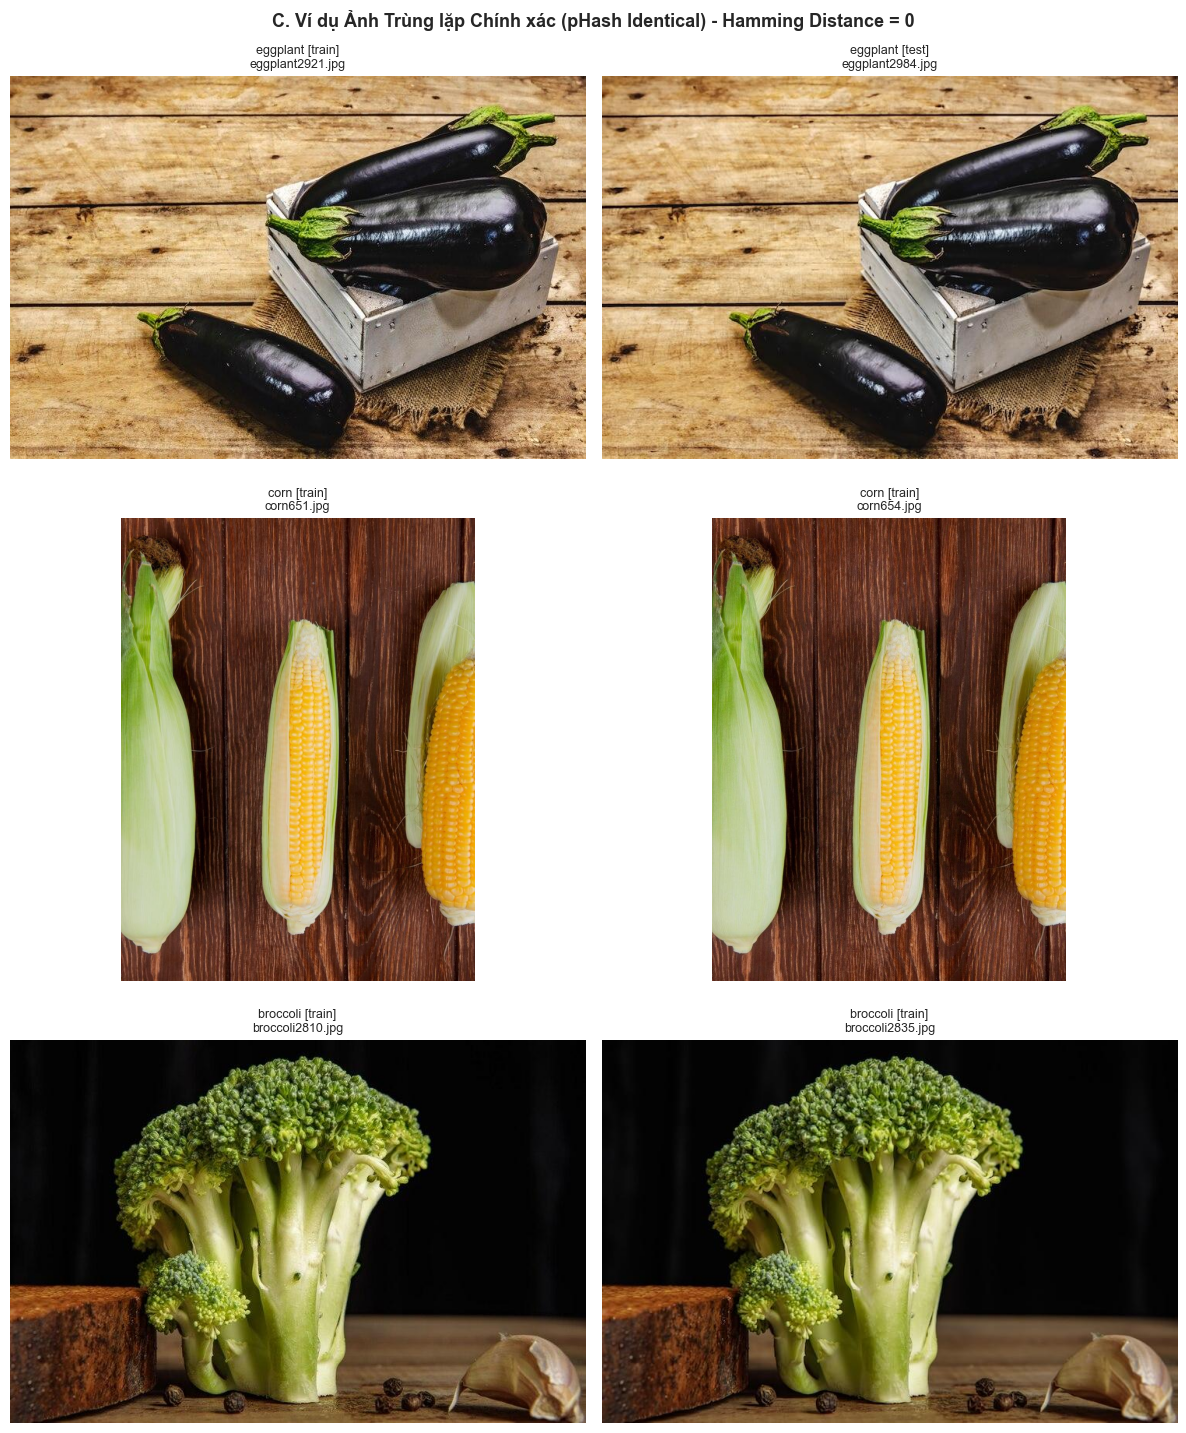

In [17]:
if len(hash_records) > 0:
	# Trực quan hóa ảnh trùng lặp chính xác - chuyển sang dạng cặp (pairs)
	dup_groups = df_hash[df_hash.duplicated('phash', keep=False)].groupby('phash')
	
	if len(dup_groups) > 0:
		# Tạo danh sách các cặp từ các nhóm trùng lặp
		exact_dup_pairs = []
		for phash_val, group in dup_groups:
				group_paths = group['path'].tolist()
				group_classes = group['class'].tolist()
				group_splits = group['split'].tolist()  # Thêm split info
				# Tạo cặp từ nhóm: ảnh đầu tiên ghép với các ảnh còn lại
				for i in range(1, len(group_paths)):
						exact_dup_pairs.append({
								'img1': group_paths[0],
								'class1': group_classes[0],
								'split1': group_splits[0],
								'img2': group_paths[i],
								'class2': group_classes[i],
								'split2': group_splits[i],
								'hamming_dist': 0  # Trùng lặp chính xác
						})
		
		# Hiển thị các cặp 
		n_pairs_show = min(3, len(exact_dup_pairs))
		
		fig, axes = plt.subplots(n_pairs_show, 2, figsize=(12, 5*n_pairs_show))
		if n_pairs_show == 1:
				axes = [axes]
		
		fig.suptitle('C. Ví dụ Ảnh Trùng lặp Chính xác (pHash Identical) - Hamming Distance = 0', 
								fontsize=13, fontweight='bold')
		
		for row_idx in range(n_pairs_show):
				pair = exact_dup_pairs[row_idx]
				
				# Ảnh 1
				ax1 = axes[row_idx][0]
				try:
						img1 = Image.open(pair['img1'])
						ax1.imshow(img1)
						ax1.set_title(f"{pair['class1']} [{pair['split1']}]\n{os.path.basename(pair['img1'])}", fontsize=9)
				except Exception:
						ax1.text(0.5, 0.5, 'Lỗi đọc ảnh', ha='center', va='center')
				ax1.axis('off')
				
				# Ảnh 2
				ax2 = axes[row_idx][1]
				try:
						img2 = Image.open(pair['img2'])
						ax2.imshow(img2)
						ax2.set_title(f"{pair['class2']} [{pair['split2']}]\n{os.path.basename(pair['img2'])}", fontsize=9)
				except Exception:
						ax2.text(0.5, 0.5, 'Lỗi đọc ảnh', ha='center', va='center')
				ax2.axis('off')
		
		plt.tight_layout()
		plt.show()
	else:
		print('Không có ảnh trùng lặp để hiển thị.')


---
## Part D - Global Brightness and Contrast Analysis

Tính Mean Intensity (độ sáng trung bình) và Standard Deviation (độ tương phản) cho từng ảnh, hiển thị qua boxplot phân lớp.


In [18]:
# Sử dụng df_pixel_stats đã tính ở Phần A
# Tính thêm: mean intensity toàn ảnh (trung bình 3 kênh) và std (độ tương phản)
df_pixel_stats['mean_intensity'] = df_pixel_stats[['mean_R', 'mean_G', 'mean_B']].mean(axis=1)
df_pixel_stats['std_intensity'] = df_pixel_stats[['std_R', 'std_G', 'std_B']].mean(axis=1)

# Thống kê theo class
stats_by_class = df_pixel_stats.groupby('class').agg(
    Mean_Intensity=('mean_intensity', 'mean'),
    Std_Intensity=('std_intensity', 'mean'),
    Mean_R=('mean_R', 'mean'),
    Mean_G=('mean_G', 'mean'),
    Mean_B=('mean_B', 'mean'),
).round(2)

brightest_class = stats_by_class["Mean_Intensity"].idxmax()
brightest_intensity = float(stats_by_class["Mean_Intensity"].max())
darkest_class = stats_by_class["Mean_Intensity"].idxmin()
darkest_intensity = float(stats_by_class["Mean_Intensity"].min())
highest_contrast_class = stats_by_class["Std_Intensity"].idxmax()
highest_contrast_value = float(stats_by_class["Std_Intensity"].max())
most_uniform_class = stats_by_class["Std_Intensity"].idxmin()
most_uniform_value = float(stats_by_class["Std_Intensity"].min())

print(stats_by_class.to_string())
print()
print(f'Class sáng nhất: {brightest_class} ({brightest_intensity:.2f})')
print(f'Class tối nhất: {darkest_class} ({darkest_intensity:.2f})')
print(f'Class tương phản cao nhất: {highest_contrast_class} ({highest_contrast_value:.2f})')
print(f'Class đồng đều nhất: {most_uniform_class} ({most_uniform_value:.2f})')

           Mean_Intensity  Std_Intensity      Mean_R      Mean_G      Mean_B
class                                                                       
asparagus      174.940002      49.630001  180.429993  183.039993  161.360001
banana         192.509995      47.610001  206.500000  203.720001  167.320007
broccoli       137.919998      48.209999  142.419998  146.360001  124.980003
carrot         191.130005      48.459999  219.279999  188.089996  166.029999
corn           167.139999      48.279999  189.970001  177.910004  133.539993
eggplant       151.940002      60.270000  164.899994  149.330002  141.600006
orange         195.910004      53.070000  231.259995  201.639999  154.809998
pineapple      176.880005      55.029999  193.789993  183.350006  153.520004
potato         159.630005      48.450001  183.500000  161.500000  133.910004
tomato         136.649994      56.000000  176.190002  122.910004  110.849998

Class sáng nhất: orange (195.91)
Class tối nhất: tomato (136.65)
Class tươn

C:\Users\Hp\AppData\Local\Temp\ipykernel_17560\3129502852.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sorted, x='class', y='mean_intensity',
C:\Users\Hp\AppData\Local\Temp\ipykernel_17560\3129502852.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sorted2, x='class', y='std_intensity',


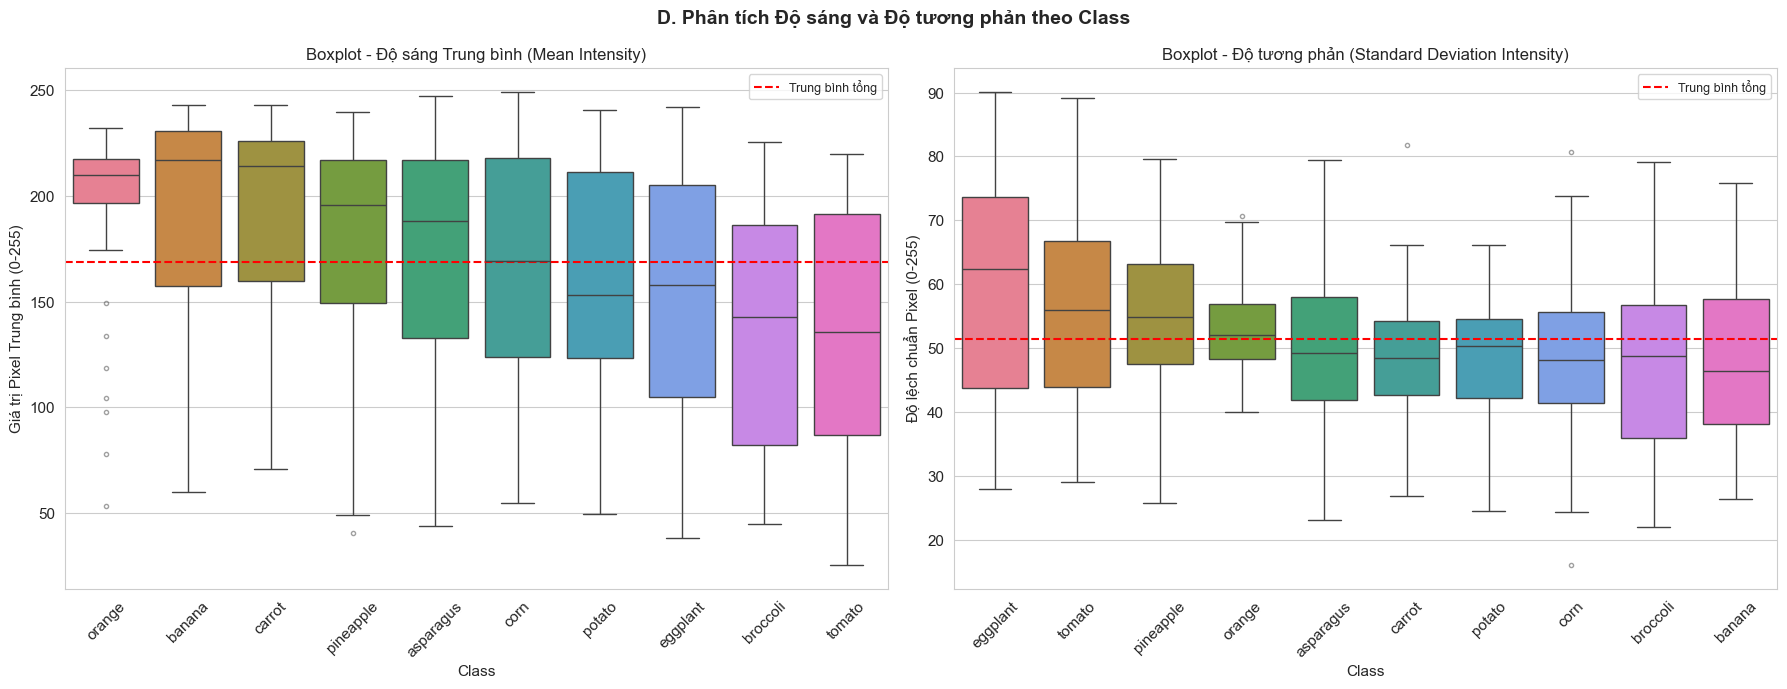

In [19]:
# Boxplot Độ sáng (Mean Intensity) theo Class
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('D. Phân tích Độ sáng và Độ tương phản theo Class', fontsize=14, fontweight='bold')

class_order = stats_by_class['Mean_Intensity'].sort_values(ascending=False).index.tolist()

# Boxplot độ sáng
ax1 = axes[0]
df_pixel_stats['class'] = pd.Categorical(df_pixel_stats['class'], categories=class_order, ordered=True)
df_sorted = df_pixel_stats.sort_values('class')

palette = sns.color_palette('husl', n_colors=len(CLASSES))
sns.boxplot(data=df_sorted, x='class', y='mean_intensity',
            palette=palette, ax=ax1, order=class_order,
            flierprops=dict(marker='o', markersize=3, alpha=0.5))
ax1.set_title('Boxplot - Độ sáng Trung bình (Mean Intensity)', fontsize=12)
ax1.set_xlabel('Class')
ax1.set_ylabel('Giá trị Pixel Trung bình (0-255)')
ax1.tick_params(axis='x', rotation=45)
ax1.axhline(y=df_pixel_stats['mean_intensity'].mean(), color='red',
            linestyle='--', linewidth=1.5, label='Trung bình tổng')
ax1.legend(fontsize=9)

# Boxplot độ tương phản
ax2 = axes[1]
std_order = stats_by_class['Std_Intensity'].sort_values(ascending=False).index.tolist()
df_pixel_stats['class'] = pd.Categorical(df_pixel_stats['class'], categories=std_order, ordered=True)
df_sorted2 = df_pixel_stats.sort_values('class')

sns.boxplot(data=df_sorted2, x='class', y='std_intensity',
            palette=palette, ax=ax2, order=std_order,
            flierprops=dict(marker='o', markersize=3, alpha=0.5))
ax2.set_title('Boxplot - Độ tương phản (Standard Deviation Intensity)', fontsize=12)
ax2.set_xlabel('Class')
ax2.set_ylabel('Độ lệch chuẩn Pixel (0-255)')
ax2.tick_params(axis='x', rotation=45)
ax2.axhline(y=df_pixel_stats['std_intensity'].mean(), color='red',
            linestyle='--', linewidth=1.5, label='Trung bình tổng')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

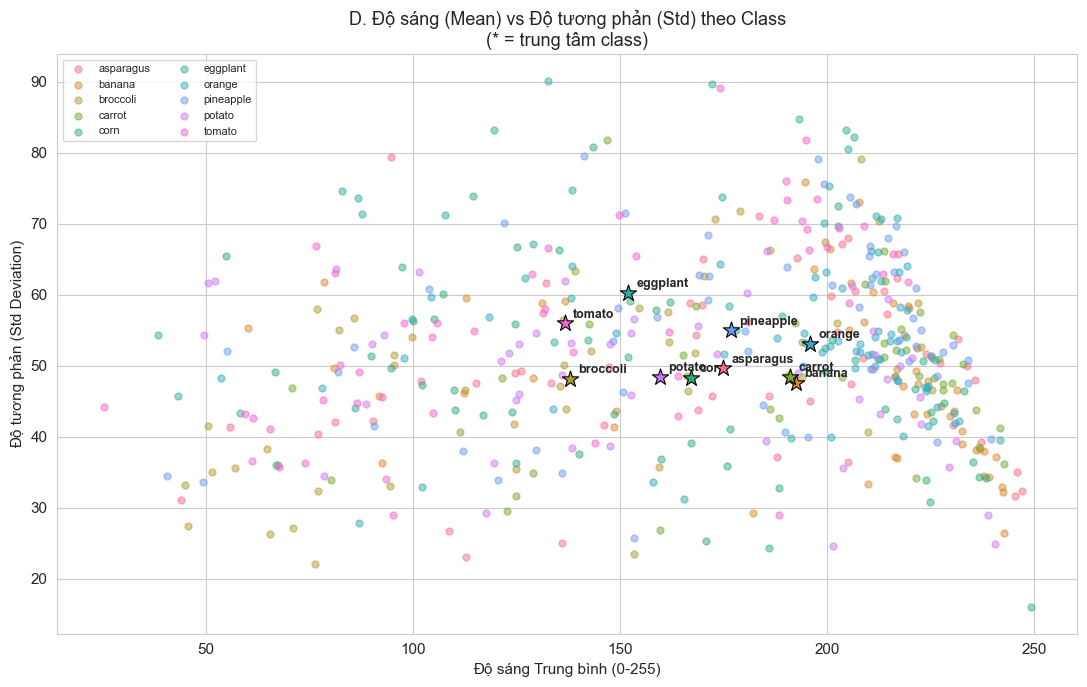

In [20]:
# Biểu đồ scatter: Độ sáng vs Độ tương phản theo Class
fig, ax = plt.subplots(figsize=(11, 7))
palette_dict = {cls: palette[i] for i, cls in enumerate(CLASSES)}

for cls in CLASSES:
    df_cls = df_pixel_stats[df_pixel_stats['class'] == cls]
    ax.scatter(df_cls['mean_intensity'], df_cls['std_intensity'],
               alpha=0.5, label=cls, s=25, color=palette_dict[cls])

# Đánh dấu trung tâm mỗi class
for cls in CLASSES:
    df_cls = df_pixel_stats[df_pixel_stats['class'] == cls]
    cx = df_cls['mean_intensity'].mean()
    cy = df_cls['std_intensity'].mean()
    ax.scatter(cx, cy, s=150, color=palette_dict[cls], marker='*',
               edgecolors='black', linewidth=0.8, zorder=5)
    ax.annotate(cls, (cx, cy), textcoords='offset points', xytext=(6, 4), fontsize=9, fontweight='bold')

ax.set_title('D. Độ sáng (Mean) vs Độ tương phản (Std) theo Class\n(* = trung tâm class)', fontsize=13)
ax.set_xlabel('Độ sáng Trung bình (0-255)')
ax.set_ylabel('Độ tương phản (Std Deviation)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

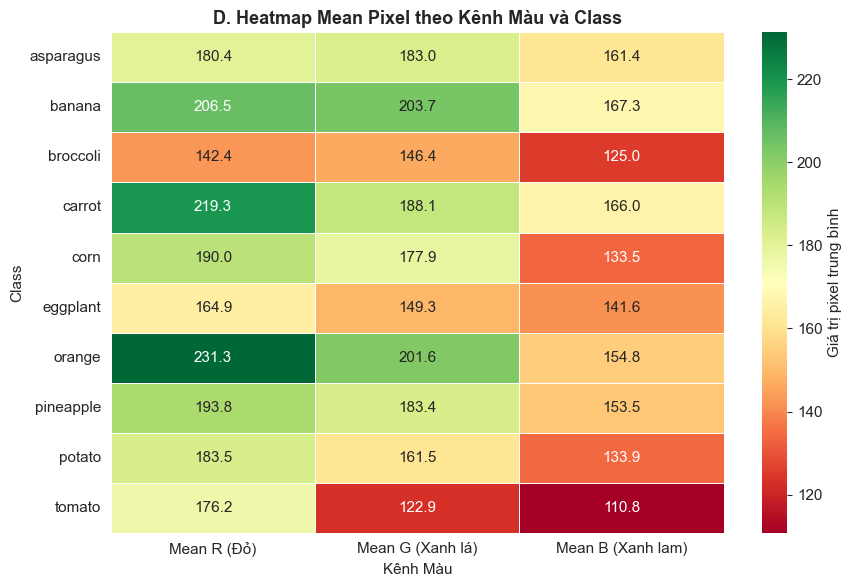

In [21]:
# Biểu đồ heatmap: Mean theo từng kênh màu và class
heatmap_data = stats_by_class[['Mean_R', 'Mean_G', 'Mean_B']]
heatmap_data.columns = ['Mean R (Đỏ)', 'Mean G (Xanh lá)', 'Mean B (Xanh lam)']

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Giá trị pixel trung bình'})
ax.set_title('D. Heatmap Mean Pixel theo Kênh Màu và Class', fontsize=13, fontweight='bold')
ax.set_ylabel('Class')
ax.set_xlabel('Kênh Màu')
plt.tight_layout()
plt.show()
